## Load input data for NJ
Load input data for the entire NJ.<br>
Input variables: P-mP, T-mT, PME, elev, slope, lnK, mwtd, WithdrawalMG

In [1]:
#Load models 
import sys
sys.path.insert(1,'/scratch/network/ym5379/WTD_estimate_YM/Scripts/models')

from random_forest import random_forest
from sklearn import linear_model

#Load models 
import torch
from torch.utils.data import Dataset
import xarray
from parflow.tools.io import read_pfb, write_pfb
import numpy as np
import pandas as pd

import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

import rioxarray

import matplotlib.pyplot as plt

/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:805: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit()
/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:837: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit()
/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:860: NumbaD

In [2]:
'''
Dataloader for WTD anomaly estimation over NJ
'''

class WTD_Anomaly_Estimation_NJ_Dataset(Dataset):
    '''
    Return input dataset used to contruct ML models for estimating water table depth (WTD) anomaly
    over NJ for a specific date.

    Input data are:
                    1. P anomaly;
                    2. T anomaly;
                    3. precipitation minus evapotranspiration (PME);
                    4. elevation (elev);
                    5. topographic slope (slope);
                    6. natural log of hydraulic conductivity (lnK);
                    7. estimated long-term mean WTD (mwtd);
                    8. Groundwater Pumping

    Output data are: water table depth anomaly (wtd_a)

    :param in_vars:
        Input variables.
    :param out_vars:
        Output variables.
    :param date:
        Study date. Format: 'YYYY-MM-DD'.
    :param base_dirs:
        Locations of data used to construct ML models. 
    '''
    def __init__(
        self,
        in_vars=None,
        out_vars=None,
        study_date=None,
        base_dirs=['/home/SHARED/data/ym5379/WTD_RF_estimates/CONUS2_input/',
                   '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/',
                   '/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/',
                   '/hydrodata/forcing/processed_data/CONUS2/CW3E/monthly/']
    ):
        super().__init__()
        self.in_vars = in_vars
        self.out_vars = out_vars
        
        #Load location files
        x_pixel_arr_all = np.load(base_dirs[2]+'x_indexes_90m_NJ.npy')
        y_pixel_arr_all = np.load(base_dirs[2]+'y_indexes_90m_NJ.npy')
        
        x_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'x_indexes_90m_Withdrawals_NJ.npy')
        y_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'y_indexes_90m_Withdrawals_NJ.npy')
        
        mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)

        mask[mask>0] = 1

        x_pixel_arr_all[np.isnan(x_pixel_arr_all)] = 0
        y_pixel_arr_all[np.isnan(y_pixel_arr_all)] = 0
        
        x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
        y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0

        n_features = len(in_vars)
        nx = x_pixel_arr_all.shape[1]
        ny = x_pixel_arr_all.shape[0]

        x_new = np.empty([n_features,nx*ny],dtype=np.float32)
    
        ##Load input data##  
        #PME
        x_new[2,:] = read_pfb(base_dirs[0]+'1km_CONUS2_PME_fixed_GPU.pfb')[9,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                  x_pixel_arr_all.reshape(-1).astype(int)]
        #lnK
        x_new[5,:] = read_pfb(base_dirs[0]+'lnK_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                    x_pixel_arr_all.reshape(-1).astype(int)]
        
        #Elev
        elev_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_DEM.tif')
        elev_dataset = elev_dataset.astype('float32')

        elev_data = elev_dataset.data
        x_new[3,:] = elev_data[0,:,:].reshape(-1)
        
        #Slope
        slope_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_slope.tif')
        slope_data = slope_dataset.data
        slope_data[slope_data==-9999.0] = np.nan
        slope_data = np.tan(slope_data*np.pi/180)
        x_new[4,:] = slope_data[0,:,:].reshape(-1)
        
        #mwtd
        x_new[6,:] = rioxarray.open_rasterio(base_dirs[2]+'wtd_mean_estimate_RF_3s_CONUS_model_NJ_m_v_20230519.tif').data[0,:,:].reshape(-1)
        
        #GW pumping
        HUC14 = rioxarray.open_rasterio(base_dirs[1]+'NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
        
        #Load Pumping data
        GW_withdrawal_dataset = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')
        GW_withdrawal_dataset['Date'] = pd.to_datetime(GW_withdrawal_dataset.YearNumber.astype(str)+'/'+GW_withdrawal_dataset.MonthNumber.astype(str)+'/01')
        GW_withdrawal_dataset = GW_withdrawal_dataset.drop(columns=['SiteName','YearNumber','MonthNumber','TransferEffectiveDate','DataSource'])

        GW_withdrawal_dataset = GW_withdrawal_dataset[GW_withdrawal_dataset['Date']==study_date]
        
        GW_withdrawal_90m_data = np.empty(ny*nx) * np.nan
        count = 0

        for HUC14_index in np.unique(HUC14[~np.isnan(HUC14)]):

            if GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)].shape[0] != 0:
                GW_withdrawal_90m_data[HUC14==HUC14_index] = GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)]['WithdrawalMG'].mean()
            else:
                count += 1
                GW_withdrawal_90m_data[HUC14==HUC14_index] = 0
        
        x_new[7,:] = GW_withdrawal_90m_data
        
        #P & T anomaly 
        year = pd.to_datetime(study_date).year
        month = pd.to_datetime(study_date).month

        #Water Year
        if month > 9:
            year_d = year + 1
            index = month - 10
        else:
            year_d = year 
            index = month + 12 - 10
        
        P_arr = read_pfb(base_dirs[3]+'CW3E.APCP.monthly.sum.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        T_arr = read_pfb(base_dirs[3]+'CW3E.Temp.monthly.mean.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]


        lmeanP_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_precipitation_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        lmeanT_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_temperature_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        
        x_new[0,:] = P_arr - lmeanP_data
        x_new[1,:] = T_arr - lmeanT_data
        
        #Set mask as nan
        mask = mask.reshape(-1) + np.isnan(x_new[5,:]) + np.isnan(x_new[3,:]) + np.isnan(x_new[4,:]) + np.isnan(x_new[6,:]) + np.isnan(x_new[7,:])
        mask[mask>1] = 1
        
        x_new[:,mask] = np.nan
        
        self.in_data = torch.from_numpy(np.stack(x_new)).type(torch.float32).reshape(n_features,-1)
        self.huc14 = torch.from_numpy(HUC14).type(torch.float32)
        
    def __getitem__(self, idx):
        return self.in_data[:,idx], self.huc14

    def __len__(self):
        return self.in_data.shape[1]

    def is_numpy(self):
        return self.in_data.numpy()

In [3]:
GW = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')
GW

,SiteName,HUC14,YearNumber,MonthNumber,TransferEffectiveDate,WithdrawalMG,DataSource
0,BWA:10000W:4500061135,2030105120040,2003,9,09/01/03 00:00:00,0.020,BWA NJEMS database
1,BWA:10000W:4500061135,2030105120040,2003,1,01/01/03 00:00:00,0.030,BWA NJEMS database
2,BWA:10000W:4500061135,2030105120040,2003,12,12/01/03 00:00:00,0.020,BWA NJEMS database
3,BWA:10000W:4500061135,2030105120040,2003,10,10/01/03 00:00:00,0.020,BWA NJEMS database
4,BWA:10000W:4500061135,2030105120040,2003,8,08/01/03 00:00:00,0.020,BWA NJEMS database
...,...,...,...,...,...,...,...
5150916,Domestic Well Withdrawals_Warren_White_G340041...,2040105110020,2001,3,03/01/01 00:00:00,2.037,NJGS
5150917,Domestic Well Withdrawals_Warren_White_G340041...,2040105110020,2001,4,04/01/01 00:00:00,2.027,NJGS
5150918,Domestic Well Withdrawals_Warren_White_G340041...,2040105110020,2001,5,05/01/01 00:00:00,2.262,NJGS
5150919,Domestic Well Withdrawals_Warren_White_G340041...,2040105110020,2001,6,06/01/01 00:00:00,2.486,NJGS


In [27]:
path = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_NJ.npy')
path

array([[3917., 3917., 3917., ..., 4051., 4051., 4051.],
       [3917., 3917., 3917., ..., 4051., 4051., 4051.],
       [3917., 3917., 3917., ..., 4051., 4051., 4051.],
       ...,
       [3988., 3988., 3988., ..., 4128., 4128., 4128.],
       [3988., 3988., 3988., ..., 4128., 4128., 4128.],
       [3988., 3988., 3988., ..., 4128., 4128., 4128.]])

In [4]:
in_vars = ['P-mP','T-mT','PME','elev','slope','lnK','mwtd','WithdrawalMG']
out_vars = ['wtd_a']

In [5]:
input_dataset = WTD_Anomaly_Estimation_NJ_Dataset(in_vars,out_vars,
                                                  study_date='2015-01-01')
    
X_tensor, huc14_tensor = input_dataset[:]
X = np.swapaxes(X_tensor.numpy(),0,1)#input shape (n_samples, n_features)
huc14 = huc14_tensor.numpy()

In [6]:
np.unique(huc14)

array([-9.9990000e+03,  2.0200070e+12,  2.0200071e+12,  2.0301012e+12,
        2.0301030e+12,  2.0301032e+12,  2.0301040e+12,  2.0301041e+12,
        2.0301049e+12,  2.0301050e+12,  2.0301051e+12,  2.0401041e+12,
        2.0401042e+12,  2.0401050e+12,  2.0401051e+12,  2.0401053e+12,
        2.0402011e+12,  2.0402020e+12,  2.0402021e+12,  2.0402061e+12,
        2.0402062e+12,  2.0402069e+12,  2.0403010e+12,  2.0403011e+12,
        2.0403012e+12,  2.0403019e+12,  2.0403020e+12,  2.0403021e+12,
        2.0403029e+12], dtype=float32)

In [5]:
X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [5]:
len(X)

6260800

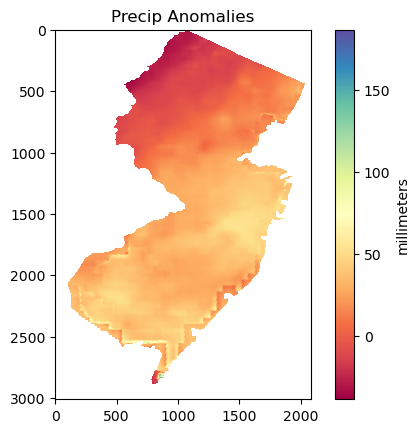

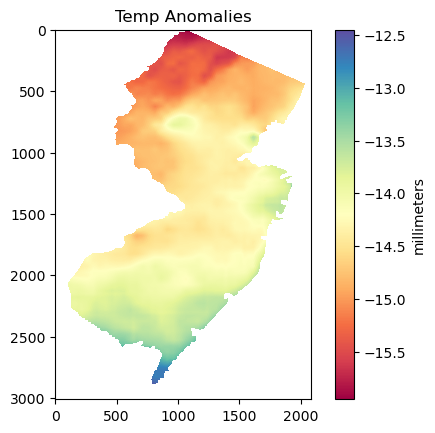

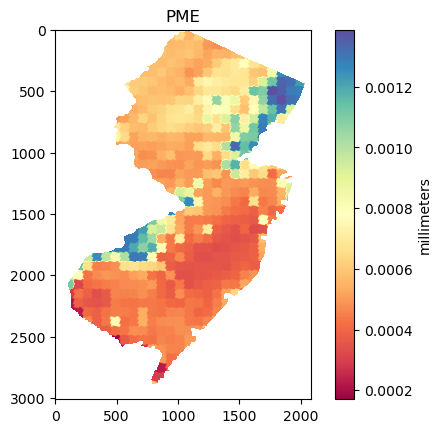

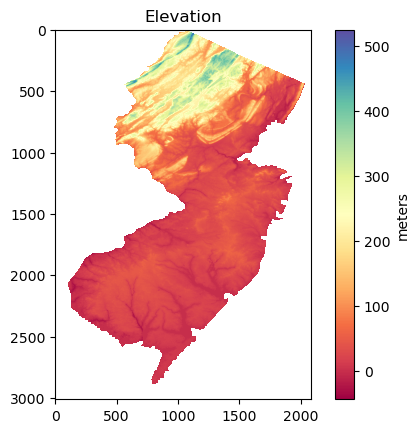

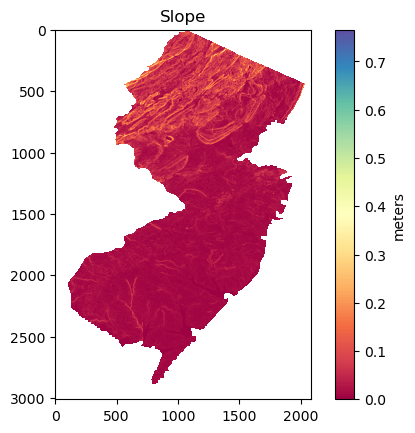

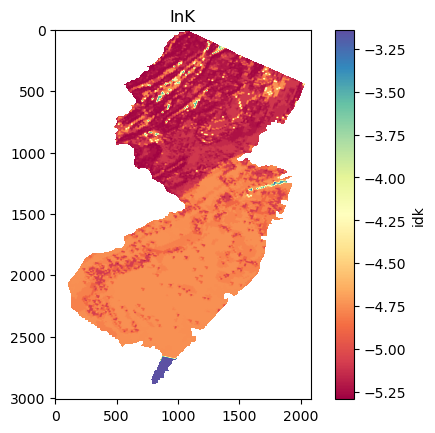

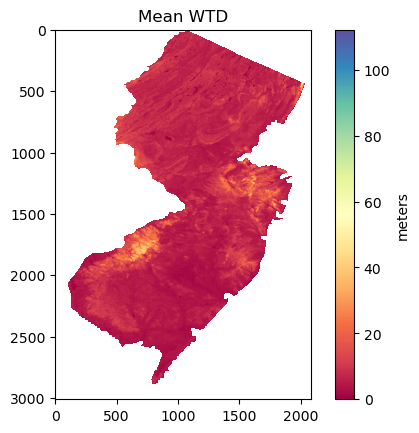

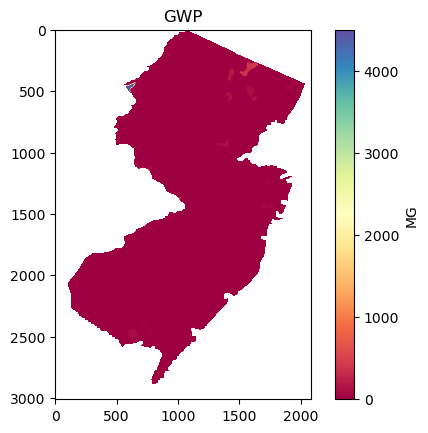

In [7]:
#Test
x_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_NJ.npy')

nx = x_pixel_arr_all.shape[1]
ny = x_pixel_arr_all.shape[0]
titles = ('Precip Anomalies', 'Temp Anomalies', 'PME', 'Elevation', 'Slope', 'lnK', 'Mean WTD', 'GWP')
labels = ('millimeters', 'millimeters', 'millimeters', 'meters', 'meters', 'idk', 'meters', 'MG')
num = []

for i, title, ylabel in zip(range(8), titles, labels):
    fig = plt.figure()
    plt.imshow(X[:, i].reshape(ny, nx), cmap='Spectral')
    plt.colorbar().set_label(ylabel)
    plt.title(title)
    plt.show()
    
# P anomaly;
# T anomaly;
# precipitation minus evapotranspiration (PME);
# elevation (elev);
# topographic slope (slope);
# natural log of hydraulic conductivity (lnK);
# estimated long-term mean WTD (mwtd);
# gw pumping

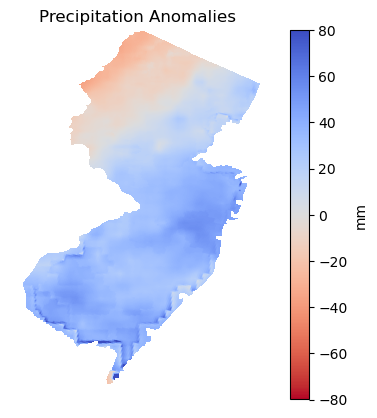

In [8]:
fig = plt.figure()
plt.imshow(X[:, 0].reshape(ny, nx), cmap='coolwarm_r')
plt.colorbar().set_label('mm')
plt.clim(-80,80)
plt.axis('off')
plt.title('Precipitation Anomalies')
plt.savefig('precip_jan.png', dpi=300)

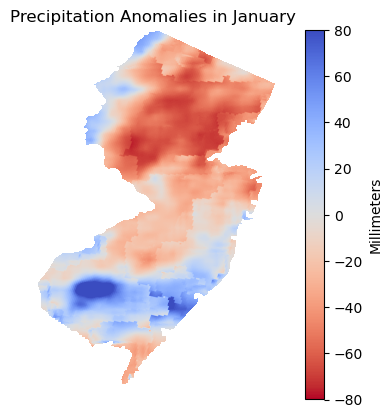

In [26]:
fig = plt.figure()
plt.imshow(X[:, 0].reshape(ny, nx), cmap='coolwarm_r')
plt.colorbar().set_label('mm')
plt.clim(-80,80)
plt.axis('off')
plt.title('Precipitation Anomalies in January')
plt.savefig('precip_july.png', dpi=300)

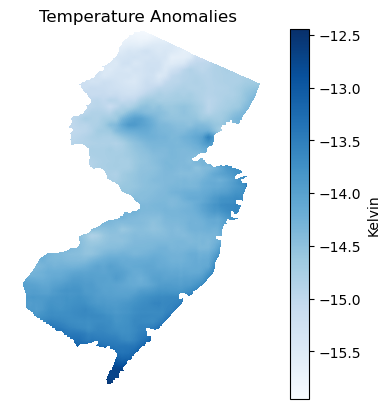

In [41]:
fig = plt.figure()
plt.imshow(X[:, 1].reshape(ny, nx), cmap='Blues')
plt.colorbar().set_label('Kelvin')
plt.axis('off')
plt.title('Temperature Anomalies')
plt.savefig('temp_jan.png', dpi=300)

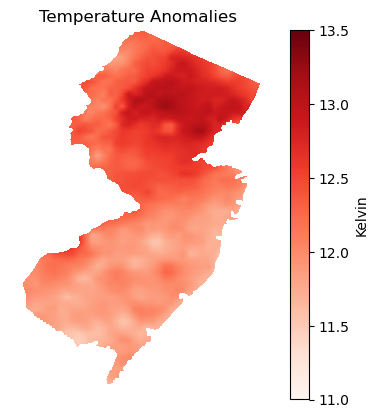

In [27]:
fig = plt.figure()
plt.imshow(X[:, 1].reshape(ny, nx), cmap='Reds')
plt.colorbar().set_label('Kelvin')
plt.clim(11,13.5)
plt.axis('off')
plt.title('Temperature Anomalies')
plt.savefig('temp_july.png', dpi=300)

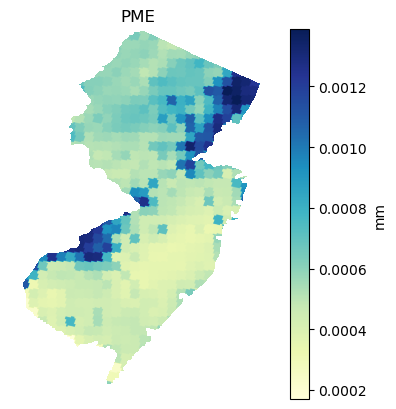

In [32]:
fig = plt.figure()
plt.imshow(X[:, 2].reshape(ny, nx), cmap='YlGnBu')
plt.colorbar().set_label('mm')
plt.title('PME')
plt.axis('off')
plt.savefig('pme.png', dpi=300)

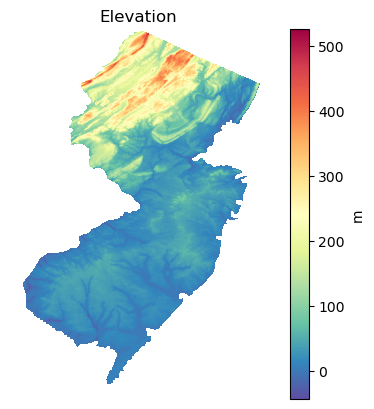

In [33]:
fig = plt.figure()
plt.imshow(X[:, 3].reshape(ny, nx), cmap='Spectral_r')
plt.colorbar().set_label('m')
plt.title('Elevation')
plt.axis('off')
plt.savefig('elev.png', dpi=300)

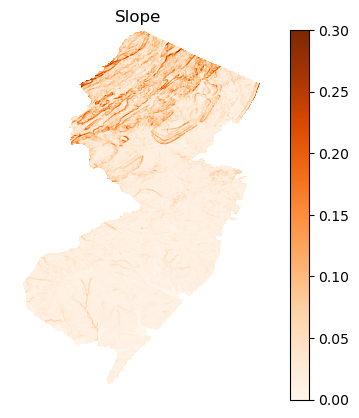

In [10]:
fig = plt.figure()
plt.imshow(X[:, 4].reshape(ny, nx), cmap='Oranges')
plt.colorbar()
plt.clim(0, 0.3)
plt.title('Slope')
plt.axis('off')
plt.savefig('slope.png', dpi=300)

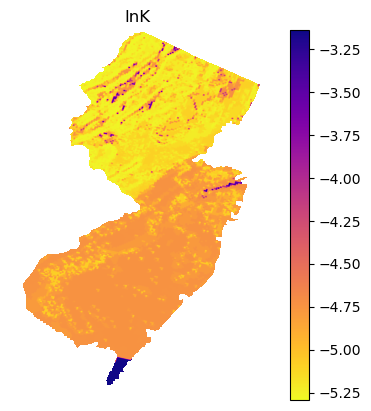

In [28]:
fig = plt.figure()
plt.imshow(X[:, 5].reshape(ny, nx), cmap='plasma_r')
plt.colorbar()
plt.title('lnK')
plt.axis('off')
plt.savefig('lnK.png', dpi=300)

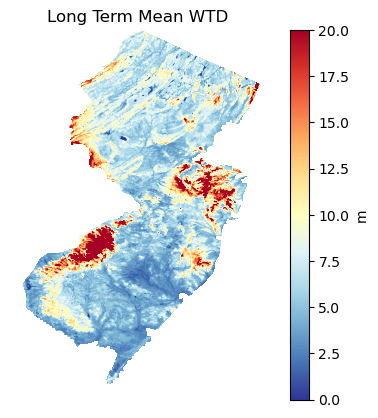

In [34]:
fig = plt.figure()
plt.imshow(X[:, 6].reshape(ny, nx), cmap='RdYlBu_r')
plt.colorbar().set_label('m')
plt.clim(0, 20)
plt.axis('off')
plt.title('Long Term Mean WTD')
plt.savefig('mwtd.png', dpi=300)

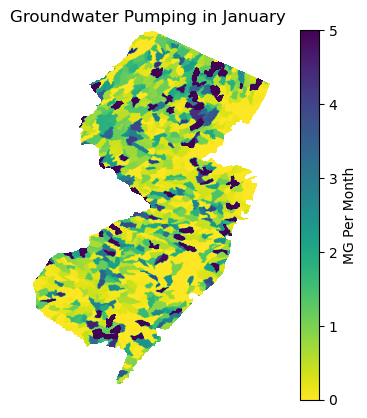

In [19]:
fig = plt.figure()
plt.imshow(X[:, 7].reshape(ny, nx), cmap='viridis_r')
plt.clim(0, 5)
plt.colorbar().set_label('MG Per Month')
plt.axis('off')
plt.title('Groundwater Pumping in January')
plt.savefig('gwp.png', dpi=300)

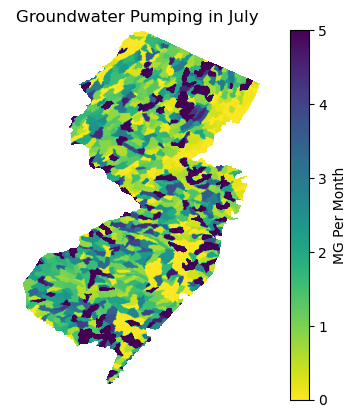

In [17]:
fig = plt.figure()
plt.imshow(X[:, 7].reshape(ny, nx), cmap='viridis_r')
plt.clim(0, 5)
plt.colorbar().set_label('MG Per Month')
plt.axis('off')
plt.title('Groundwater Pumping in July')
plt.savefig('gwp.png', dpi=300)

In [ ]:
in_vars = ['P-mP','T-mT','PME','elev','slope','lnK','mwtd','WithdrawalMG']

In [10]:
pump_pred = pd.read_csv('/home/jk48/Senior_Thesis/pumping_predictions')
pump_pred

,Unnamed: 0,y_true,y_pred,x,y,rmse
0,0,0.027,0.148571,7208,26030,-0.121571
1,1,0.037,0.022285,7208,26030,0.014715
2,2,0.030,0.107967,7208,26030,-0.077967
3,3,0.019,0.152335,7208,26030,-0.133335
4,4,0.030,0.320312,7208,26030,-0.290312
...,...,...,...,...,...,...
9451,9451,0.330,0.373715,7661,2198,-0.043715
9452,9452,0.253,0.237510,7661,2198,0.015490
9453,9453,0.233,0.240856,7661,2198,-0.007856
9454,9454,0.281,0.218261,7661,2198,0.062739


In [22]:
X_pixel_array = np.ones((200, 200))  # Replace this with your image data
X_pixel_array.fill(1)
pump_pred_array = pump_pred.values
plt.imshow(pump_pred_array[:,2].reshape(ny,nx))
plt.colorbar()
plt.show()

ValueError: cannot reshape array of size 9456 into shape (3010,2080)

In [21]:
pump_pred_array[:,2]

array([0.14857058, 0.0222846 , 0.10796661, ..., 0.24085618, 0.21826118,
       0.75101765])